# Deep Q-Networks (DQN) 

## 1. The CartPole Task

We test with CartPole  a classic benchmark that's fast to train.

The setup: a pole is balanced on top of a cart that can slide left or right. At every timestep, you choose push left or push right. You get +1 reward for every timestep the pole stays upright. The episode ends when the pole falls over, or after 500 steps.

Solved = average reward ≥ 475 over 100 consecutive episodes, meaning the agent is balancing the pole for nearly the full 500 steps, consistently.

The state the agent observes at each step is just 4 numbers:

| # | Variable | What it means |
|---|----------|---------------|
| 1 | Cart position | Where the cart is on the track |
| 2 | Cart velocity | How fast the cart is moving |
| 3 | Pole angle | How tilted the pole is |
| 4 | Pole angular velocity | How fast the pole is falling |


Plain Q-learning stores Q(s, a) in a table one row per state, one column per action which works fine for small problems, but not for complex ones.

| Environment | State space |
|-------------|-------------|
| CartPole | 4 continuous values → infinite possible states |
| Atari Pong | 84×84 pixels × 4 frames → more states than atoms in the universe |

We can't build a table that large. So we replace the table with a neural network that takes a state as input and outputs a Q-value for every action, this is Deep Q-Learning. The network generalizes if it has seen a state like this before, it can give a reasonable Q estimate for a state it has never seen exactly.

---

## 2. Q-Learning

Q-learning is a model-free, off-policy algorithm that directly estimates $q^*$ without requiring knowledge of the transition function $\mathcal{T}$ or reward function $r$.

Starting from an arbitrary initialisation $Q(s, a)$, the algorithm updates its estimates using observed transitions $(s, a, r, s')$:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ \underbrace{r + \gamma \max_{a'} Q(s', a')}_{\text{TD target}} - \underbrace{Q(s, a)}_{\text{current estimate}} \right]$$

The term in brackets is the Temporal Difference (TD) error $\delta_t$:

$$\delta_t = r + \gamma \max_{a'} Q(s', a') - Q(s, a)$$

This error measures how wrong our current Q-estimate is, given what we just observed. The update shrinks this error by a step in the direction of the TD target. Under standard conditions, Q-learning converges to $q^*$ for finite state and action spaces.

---

## 3. Deep Q-Networks 

DQN introduces two mechanisms that make training converge reliably.

### 3.1 The Loss Function

We train the network by minimising the mean squared Bellman error. For a sampled transition $(s, a, r, s', \text{done})$, the target value is:

$$y = \begin{cases} r & \text{if done} \\ r + \gamma \max_{a'} Q_{\theta^-}(s', a') & \text{otherwise} \end{cases}$$

The loss is:

$$\mathcal{L}(\theta) = \mathbb{E} \left[ \left( y - Q_\theta(s, a) \right)^2 \right]$$

In practice we use the Huber loss (smooth L1), which is quadratic for small errors and linear for large ones. This reduces sensitivity to outliers caused by large initial Q-value estimates:

$$\mathcal{L}_\delta(y, \hat{y}) = \begin{cases} \frac{1}{2}(y - \hat{y})^2 & \text{if } |y - \hat{y}| \leq \delta \\ \delta \left(|y - \hat{y}| - \frac{1}{2}\delta\right) & \text{otherwise} \end{cases}$$

The gradient of the loss with respect to $\theta$ is:

$$\nabla_\theta \mathcal{L}(\theta) = \mathbb{E} \left[ \left( y - Q_\theta(s, a) \right) \nabla_\theta Q_\theta(s, a) \right]$$

Note that the gradient does not flow through the target $y$, it is treated as a fixed constant during each update.

### 3.2 Experience Replay

At each step $t$, the agent stores the transition $(S_t, A_t, R_{t+1}, S_{t+1}, \text{done}_t)$ in a circular replay buffer $\mathcal{D}$ of fixed capacity $N$.

During each gradient update, a mini-batch $\mathcal{B} \sim \mathcal{D}$ of size $B$ is sampled uniformly at random. The loss is computed over this batch:

$$\mathcal{L}(\theta) = \frac{1}{B} \sum_{(s,a,r,s',d) \in \mathcal{B}} \left( y - Q_\theta(s, a) \right)^2$$

This serves two purposes. First, consecutive environment steps are highly correlated a policy that learns from them sequentially can overfit to local patterns in the trajectory. Uniform random sampling from the buffer breaks this correlation. Second, rare but informative transitions (such as the first time the agent receives a high reward) can be replayed many times, rather than being discarded after a single use.

### 3.3 The Target Network

The second source of instability is more subtle. The training target $y = r + \gamma \max_{a'} Q_\theta(s', a')$ depends on the same parameters $\theta$ that we are updating. Every gradient step moves $\theta$, which immediately changes the targets, creating a feedback loop that can cause oscillation or divergence.

The fix is to maintain two networks with identical architectures:

- The policy network $Q_\theta$, updated at every gradient step
- The target network $Q_{\theta^-}$, whose weights are copied from $\theta$ every $C$ steps and held fixed in between

The target becomes:

$$y = r + \gamma \max_{a'} Q_{\theta^-}(s', a')$$

Because $\theta^-$ is frozen, the targets are stationary for $C$ steps, giving the policy network a stable signal to learn from. In our implementation, $C = 1{,}000$.

---

## 4. The Full Training Loop

```
for each frame:
    1. Observe current state s
    2. Pick action a  (random with prob ε, else best Q value)
    3. Execute a, observe reward r and next state s'
    4. Store (s, a, r, s', done) in replay buffer
    5. Sample random mini-batch from buffer
    6. Compute targets:  y = r + γ · max_a' Q_target(s', a')
    7. Minimize loss:    L = (Q_policy(s, a) - y)²
    8. Every 1,000 steps: copy policy net weights → target net
```

---

## 5.  ε-Greedy

The agent needs to explore to discover better strategies but also exploit use what it already knows. We balance this with ε-greedy:

- With probability ε → take a random action 
- With probability 1 - ε → take the best known action 

ε starts at 1.0 and decays to 0.01 over training. In our script, the full decay happens over 10,000 frames, which is fast because CartPole doesn't need much exploration.

---

## 6. Our Network Architecture

For CartPole, the state is just 4 numbers — no need for convolutions. We use a simple 3-layer MLP:

```
Input (4)  →  Hidden (128, ReLU)  →  Hidden (128, ReLU)  →  Output (2)
                                                          [Q(left), Q(right)]
```

For Atari games, the input becomes stacked 84×84 grayscale frames which needs to be swapped with convolutional architecture...

---

## 7. Key Hyperparameters

| Parameter | Value | Why |
|-----------|-------|-----|
| `GAMMA` | 0.99 | High discount, for long-term balance |
| `BATCH_SIZE` | 64 | 
| `REPLAY_CAPACITY` | 50,000 | 
| `TARGET_UPDATE` | 1,000 steps | Sync target net frequently for CartPole's episodes |
| `EPS_DECAY_FRAMES` | 10,000 | Decay fast CartPole doesn't require much exploration to solve |
| `LEARNING_RATE` | 1e-3 | 
| `MIN_REPLAY_SIZE` | 1,000 | Wait for diverse experiences in the buffer before the first update |


*Based on: Mnih et al. (2015) "Human-level control through deep reinforcement learning", Nature 518. And: Hessel et al. (2018) "Rainbow: Combining Improvements in Deep Reinforcement Learning", AAAI-18.*

cpu
 DQN — CartPole
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 229  mean_R=  23.4  eps=0.505  loss=0.0222  fps=783  6s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 275  mean_R=  63.4  eps=0.010  loss=0.0387  fps=658  15s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 298  mean_R= 108.4  eps=0.010  loss=0.0569  fps=625  24s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 337  mean_R= 142.7  eps=0.010  loss=0.0727  fps=608  33s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 381  mean_R= 136.2  eps=0.010  loss=0.0818  fps=596  42s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 405  mean_R= 137.6  eps=0.010  loss=0.0760  fps=587  51s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 441  mean_R= 144.1  eps=0.010  loss=0.0803  fps=580  60s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 488  mean_R= 133.4  eps=0.010  loss=0.1133  fps=575  70s
[███░░░░░░░░░░░░░░░░░] 45,000/250,000  ep= 533  mean_R= 109.5  eps=0.010  loss=0.1373  fps=570  79s
[████░░

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\DQNModel.py:212: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt 

500.0
Plot saved → dqn_rewards.png


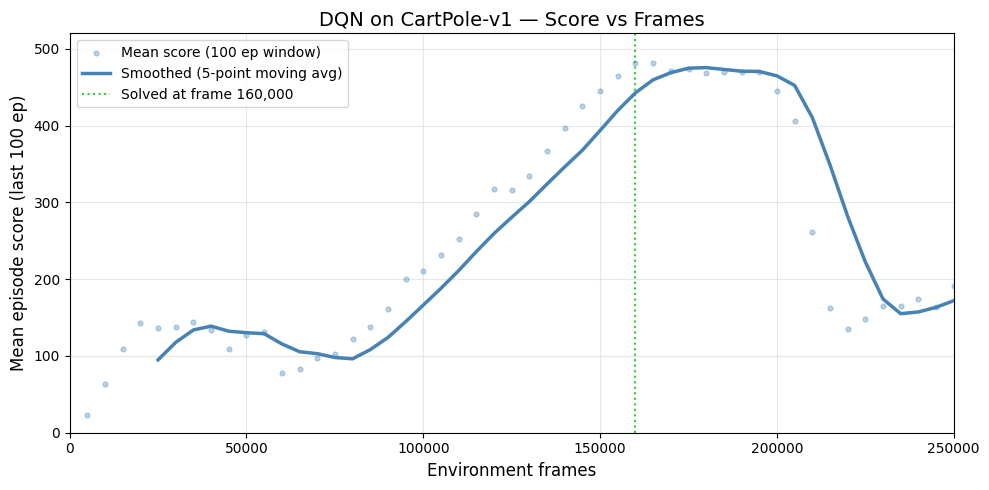

In [1]:
from DQNModel import DQNConfig, DQNAgent, train, plot_results

cfg = DQNConfig(max_frames=250000, learning_rate=5e-4, render=False)
results = train(cfg)
results.agent.save("Trained Models/DQNModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = DQNAgent(env, DQNConfig())
agent.load("Trained Models/DQNModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(results)

In [ ]:
import gymnasium as gym
from DQNModel import DQNConfig, DQNAgent

env   = gym.make("CartPole-v1", render_mode="human")
agent = DQNAgent(env, DQNConfig())
agent.load("Trained Models/DQNModel.pt")

agent.evaluate(env, n_episodes=5)
env.close()

# Double DQN

Let's take a close look at the difference between DQN and Double-DQN. The max operator in standard Q-learning and DQN uses the same values both to select and to evaluate an action. This makes it more likely to select overestimated values, resulting in overoptimistic value estimates.

$$
\theta_{t+1} = \theta_t + \alpha \big(Y_t^Q - Q(S_t, A_t; \theta_t)\big) \cdot \nabla_{\theta_t} Q(S_t, A_t; \theta_t),\\
\text{where } \alpha \text{ is a scalar step size and the target } Y_t^Q \text{is defined as }\\
Y_t^Q = R_{t+1} + \gamma \max_a Q(S_{t+1}, a; \theta_t).
$$

In Double Q-learning, two value functions are learned by assigning experiences randomly to update one of the two value functions, resulting in two sets of weights, $\theta$ and $\theta'$. For each update, one set of weights is used to determine the greedy policy and the other to determine its value. For a clear comparison, we can untangle the selection and evaluation in Q-learning and rewrite DQN's target as

$$
Y_t^Q = R_{t+1} + \gamma Q(S_{t+1}, \arg\max_a Q(S_{t+1}, a; \theta_t); \theta_t).
$$

The Double Q-learning error can then be written as

$$
Y_t^{DoubleQ} = R_{t+1} + \gamma Q(S_{t+1}, \arg\max_a Q(S_{t+1}, a; \theta_t); \theta_t').
$$

The idea of Double Q-learning is to reduce overestimations by decomposing the max operation in the target into action selection and action evaluation. Although not fully decoupled, the target network in the DQN architecture provides a natural candidate for the second value function, without having to introduce additional networks. In conclusion, the weights of the second network $\theta_t'$ are replaced with the weights of the target network for the evaluation of the current greedy policy. This makes just a small change in calculating the target value of DQN loss.

##### DQN:

```
target = reward + gamma * dqn_target(next_state).max(dim=1, keepdim=True)[0]
```

##### DoubleDQN:

```
selected_action = dqn(next_state).argmax(dim=1, keepdim=True)
target = reward + gamma * dqn_target(next_state).gather(1, selected_action)
```
      

Double-Q — CartPole
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 218  mean_R=  24.6  eps=0.505  loss=0.0206  fps=312  16s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 278  mean_R=  62.2  eps=0.010  loss=0.0457  fps=277  36s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 320  mean_R=  97.7  eps=0.010  loss=0.0870  fps=267  56s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 377  mean_R= 101.4  eps=0.010  loss=0.1146  fps=265  75s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 429  mean_R=  92.5  eps=0.010  loss=0.1193  fps=264  95s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 472  mean_R= 103.9  eps=0.010  loss=0.1289  fps=262  114s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 519  mean_R= 110.7  eps=0.010  loss=0.1437  fps=262  133s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 562  mean_R= 112.5  eps=0.010  loss=0.1546  fps=261  153s
[███░░░░░░░░░░░░░░░░░] 45,000/250,000  ep= 598  mean_R= 122.6  eps=0.010  loss=0.1597  fps=259  174s
[█

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\DoubleQModel.py:231: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

500.0
Plot saved → ddqn_rewards.png


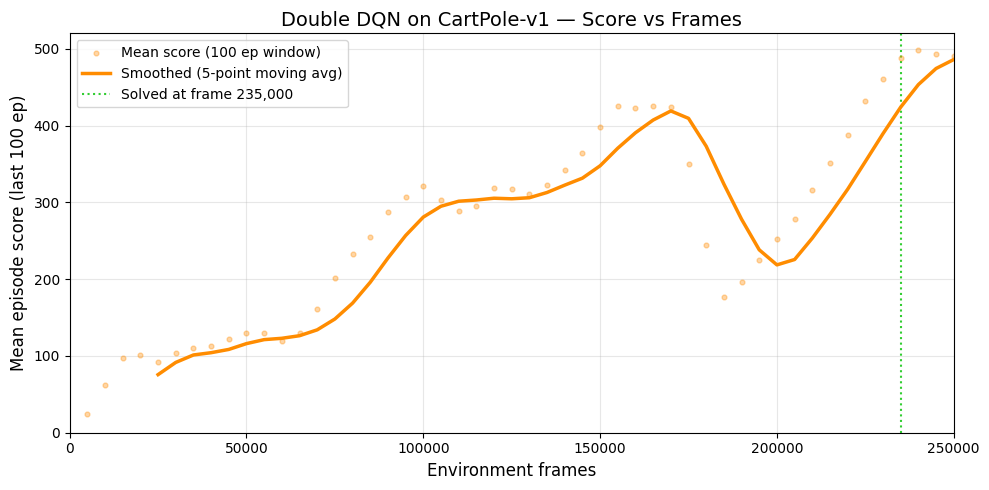

In [ ]:
from DoubleQModel import DDQNConfig, DDQNAgent, train, plot_results

cfg = DDQNConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsDDQN = train(cfg)
resultsDDQN.agent.save("Trained Models/DDQNModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = DDQNAgent(env, DDQNConfig())
agent.load("Trained Models/DDQNModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsDDQN)

In [2]:
import gymnasium as gym
from DoubleQModel import DDQNConfig, DDQNAgent

env   = gym.make("CartPole-v1", render_mode="human")
agent = DDQNAgent(env, DDQNConfig())
agent.load("Trained Models/DDQNModel.pt")

agent.evaluate(env, n_episodes=5)
env.close()

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\DoubleQModel.py:231: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

Checkpoint loaded ← Trained Models/DDQNModel.pt  (step 250,000)


# Noisy Networks 

ε-greedy takes random actions at the same rate everywhere, regardless of whether the agent already knows what to do in a given state.

Noisy Nets replace this with learned noise inside the network itself. Every linear layer becomes stochastic, and the agent learns how much to explore in each part of the state space.

## NoisyLinear Layer

A standard linear layer computes $y = Wx + b$.

A NoisyLinear layer replaces each weight and bias with a distribution:

$$y = \underbrace{(\mu^w + \sigma^w \odot \varepsilon^w)}_{\text{noisy weight}} x \;+\; \underbrace{(\mu^b + \sigma^b \odot \varepsilon^b)}_{\text{noisy bias}}$$

- $\mu, \sigma$ — learnable parameters, trained by backprop
- $\varepsilon$ — sampled noise, redrawn each gradient step

The $\sigma$ parameters control how much noise each layer injects. The network learns to shrink $\sigma \to 0$ where it is confident, and keep $\sigma$ large where it is still uncertain this is self-annealing.

## Factorised Noise

To keep noise generation cheap, instead of sampling $p \times q$ independent variables for a $(p \to q)$ layer, we sample only $p + q$ values and construct the noise via an outer product:

$$\varepsilon^w_{ij} = f(\varepsilon_j) \cdot f(\varepsilon_i), \qquad f(x) = \text{sgn}(x)\sqrt{|x|}$$

Cost drops from $\mathcal{O}(pq)$ to $\mathcal{O}(p + q)$.


In code, we replace in DQNModel `nn.Linear` → `NoisyLinear`, remove ε-greedy, call `reset_noise()` before each gradient step.

 Noisy DQN 
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 315  mean_R=  21.2  σ=0.0576  loss=0.1057  fps=191  26s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 365  mean_R=  62.6  σ=0.0385  loss=0.1205  fps=174  57s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 395  mean_R= 105.0  σ=0.0265  loss=0.1135  fps=169  89s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 438  mean_R= 131.2  σ=0.0223  loss=0.1460  fps=168  119s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 477  mean_R= 125.6  σ=0.0217  loss=0.1705  fps=167  150s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 510  mean_R= 132.1  σ=0.0204  loss=0.1874  fps=167  180s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 545  mean_R= 140.6  σ=0.0212  loss=0.2067  fps=166  210s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 579  mean_R= 147.0  σ=0.0195  loss=0.2182  fps=166  241s
[███░░░░░░░░░░░░░░░░░] 45,000/250,000  ep= 616  mean_R= 141.6  σ=0.0202  loss=0.2413  fps=162  278s
[████░░░░░░░░░░░░

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\NoisyModel.py:302: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckp

500.0
Plot saved → noisy_dqn_rewards.png


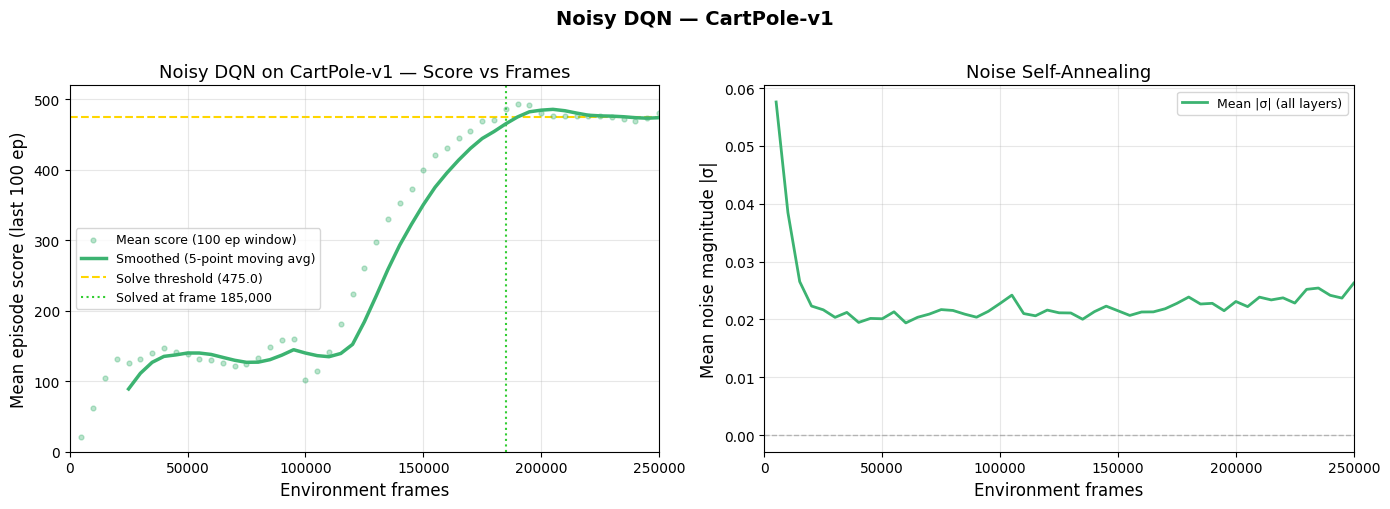

In [3]:
from NoisyModel import NoisyDQNAgent, NoisyDQNConfig, train, plot_results

cfg = NoisyDQNConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsNoisy = train(cfg)
resultsNoisy.agent.save("Trained Models/NoisyModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = NoisyDQNAgent(env, NoisyDQNConfig())
agent.load("Trained Models/NoisyModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsNoisy)

In [ ]:
import gymnasium as gym
from NoisyModel import NoisyDQNAgent, NoisyDQNConfig

env   = gym.make("CartPole-v1", render_mode="human")
agent = NoisyDQNAgent(env, NoisyDQNConfig())
agent.load("Trained Models/NoisyModel.pt")

agent.evaluate(env, n_episodes=3)
env.close()

Checkpoint loaded ← Trained Models/NoisyModel.pt  (step 250,000)


# Prioritized Experience Replay 

Simple DQN samples transitions uniformly from the replay buffer every past experience has the same probability of being replayed. This is wasteful. Some transitions carry a large TD error and teach the agent a lot, others have near-zero error and teach it almost nothing.

PER samples transitions proportional to how much the agent still has to learn from them, measured by the absolute TD error $|\delta_i|$.

## Sampling Distribution

Each transition $i$ is assigned a priority:

$$p_i = |\delta_i| + \varepsilon$$

where $\varepsilon$ is a small constant to ensure no transition has zero probability. The sampling probability is then:

$$P(i) = \frac{p_i^\alpha}{\sum_j p_j^\alpha}$$

- $\alpha = 0$ → uniform sampling (vanilla DQN)
- $\alpha = 1$ → fully greedy, always sample the highest-error transition
- $\alpha = 0.5$ is the used in ref paper (Rainbow)

New transitions are inserted with the maximum current priority so they are always sampled at least once before their TD error is known.

After each gradient step, fresh TD errors $|\delta_i|$ are computed for every transition in the mini-batch and written back to the buffer. This keeps priorities current as the Q-network improves.

## The Sum-Tree

Sampling $N$ transitions naively by priority would cost $O(N)$ per step. PER uses a binary sum-tree to reduce this to $O(\log N)$:

- Each leaf stores one transition's priority $p_i^\alpha$
- Each internal node stores the sum of its two children
- The root stores $\sum_j p_j^\alpha$

Sampling draws $u \sim \mathcal{U}[0, \sum p_j^\alpha]$ and traverses the tree to find which leaf owns that value equivalent to throwing a dart on a number line where each transition owns a segment proportional to its priority.


*Reference: Schaul et al. (2015), "Prioritized Experience Replay", ICLR 2016. Hessel et al. (2018)*

PERDQN - CartPole
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 209  mean_R=  26.7  eps=0.505  β=0.412  loss=0.0156  fps=201  25s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 259  mean_R=  65.9  eps=0.010  β=0.424  loss=0.0340  fps=178  56s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 297  mean_R= 104.9  eps=0.010  β=0.436  loss=0.0670  fps=171  88s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 336  mean_R= 130.2  eps=0.010  β=0.448  loss=0.0905  fps=168  119s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 377  mean_R= 128.7  eps=0.010  β=0.460  loss=0.1249  fps=165  151s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 418  mean_R= 122.4  eps=0.010  β=0.472  loss=0.1229  fps=164  183s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 456  mean_R= 125.8  eps=0.010  β=0.484  loss=0.0791  fps=163  215s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 492  mean_R= 130.9  eps=0.010  β=0.496  loss=0.0517  fps=162  247s
[███░░░░░░░░░░░░░░░░░] 45,000/2

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\PReplayModel.py:360: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

168.85
Plot saved → per_dqn_rewards.png


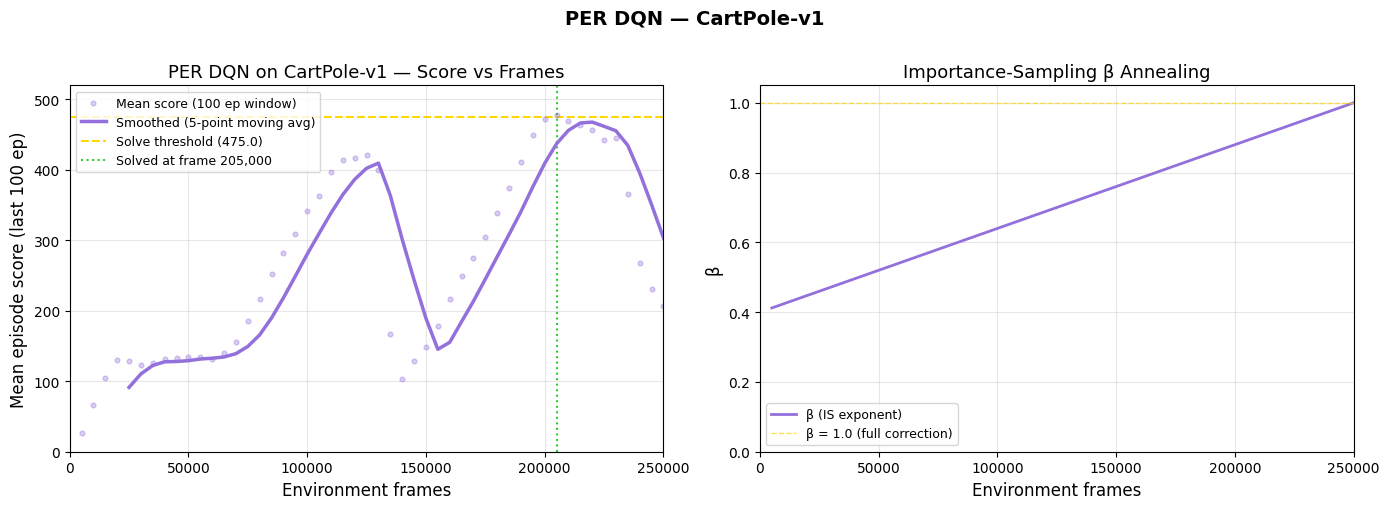

In [1]:
from PReplayModel import PERAgent, PERConfig, train, plot_results

cfg = PERConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsPER = train(cfg)
resultsPER.agent.save("Trained Models/PERModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = PERAgent(env, PERConfig())
agent.load("Trained Models/PERModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsPER)

In [ ]:
import gymnasium as gym
from PReplayModel import PERAgent, PERConfig

env   = gym.make("CartPole-v1", render_mode="human")
agent = PERAgent(env, PERConfig())
agent.load("Trained Models/PERModel.pt")

agent.evaluate(env, n_episodes=3)
env.close()

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\PReplayModel.py:360: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

Checkpoint loaded ← Trained Models/PERModel.pt  (step 250,000)


# Multi-Step DQN

## The Problem with Single-Step Bootstrapping

Vanilla DQN updates Q-values using a one-step TD target:

$$y = r_t + \gamma \max_{a'} Q(s_{t+1}, a')$$

The reward $r_t$ is real, but everything beyond it is estimated by the Q-network. Early in training, when Q-values are inaccurate, this means the agent is learning from a heavily biased signal it only gets one real data point per update before relying on its own (poor) estimates.

A reward received at step $t+5$ takes five separate gradient steps to propagate back to influence $Q(s_t, a_t)$. Multi-step returns fix this.


## The n-Step Return

Instead of bootstrapping after one step, accumulate $n$ real rewards before bootstrapping:

$$G_t^{(n)} = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots + \gamma^{n-1} r_{t+n-1}$$

The TD target becomes:

$$y = G_t^{(n)} + \gamma^n \max_{a'} Q_{\theta^-}(s_{t+n}, a')$$

Two things change relative to the 1-step case:

- The reward term $G_t^{(n)}$ contains $n$ real observed rewards instead of one.
- The bootstrap discount is $\gamma^n$ instead of $\gamma$, because the target state $s_{t+n}$ is $n$ steps ahead.

Setting $n = 1$ recovers vanilla DQN 

## Bias–Variance Trade-off

Multi-step returns sit on a spectrum between two extremes:

| | $n = 1$  | $n$ big |
|---|---|---|
| Bias | High — bootstraps from inaccurate Q | Zero — uses only real rewards |
| Variance | Low — one reward, rest estimated | High — full episode of noise |
| Propagation speed | Slow | Instant |

$n = 3$ is the Rainbow default 

## The n-Step Buffer

In code, a small circular buffer holds the last $n$ raw transitions. When it is full it emits one combined transition:

$$\underbrace{(s_t, a_t)}_{\text{oldest entry}}, \quad G_t^{(n)}, \quad \underbrace{(s_{t+n}, \text{done})}_{\text{newest entry}}$$

This is what gets stored in the replay buffer. The rest of the agent network, optimizer, target sync, ε-greedy is unchanged.

At episode end, the buffer is flushed: any remaining partial transitions (fewer than $n$ steps before the terminal state) are emitted as shorter-horizon returns so no experience is discarded.



MultiStep DQN — CartPole
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 160  mean_R=  36.8  eps=0.505  loss=0.1779  fps=355  14s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 188  mean_R=  81.8  eps=0.010  loss=0.5126  fps=290  34s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 210  mean_R= 127.2  eps=0.010  loss=0.7340  fps=278  54s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 232  mean_R= 170.9  eps=0.010  loss=0.8076  fps=274  73s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 255  mean_R= 204.3  eps=0.010  loss=0.8270  fps=272  92s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 274  mean_R= 224.2  eps=0.010  loss=0.8550  fps=270  111s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 295  mean_R= 233.6  eps=0.010  loss=0.8496  fps=265  132s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 317  mean_R= 230.0  eps=0.010  loss=0.8330  fps=262  153s
[███░░░░░░░░░░░░░░░░░] 45,000/250,000  ep= 334  mean_R= 244.3  eps=0.010  loss=0.7674  fps=260  17

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\MultiStepModel.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 

500.0
Plot saved → multistep_dqn_rewards.png


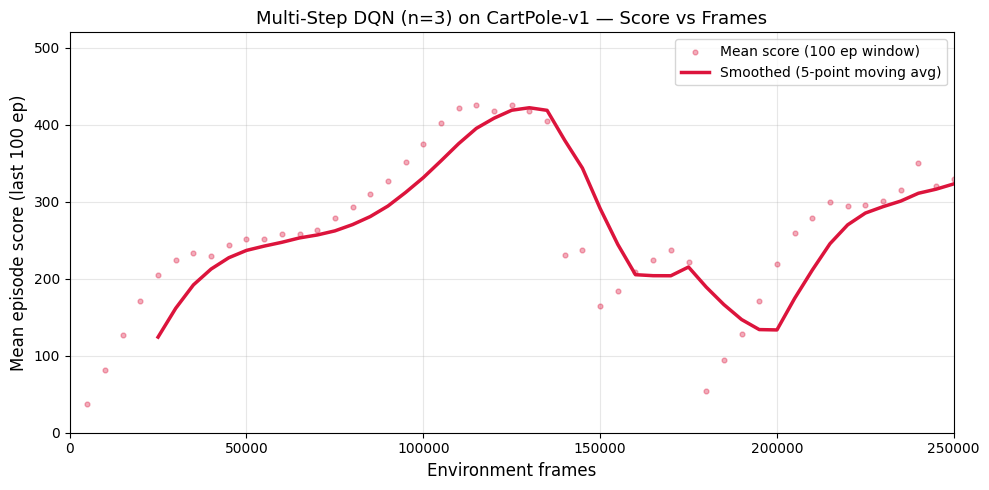

In [ ]:
from MultiStepModel import MultiStepAgent, MultiStepConfig, train, plot_results

cfg = MultiStepConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsMultiS = train(cfg)
resultsMultiS.agent.save("Trained Models/MultiStepModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = MultiStepAgent(env, MultiStepConfig())
agent.load("Trained Models/MultiStepModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsMultiS)

In [2]:
import gymnasium as gym
from MultiStepModel import MultiStepAgent, MultiStepConfig

env   = gym.make("CartPole-v1", render_mode="human")
agent = MultiStepAgent(env, MultiStepConfig())
agent.load("Trained Models/MultiStepModel.pt")

agent.evaluate(env, n_episodes=3)
env.close()

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\MultiStepModel.py:300: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
 

Checkpoint loaded ← Trained Models/MultiStepModel.pt  (step 250,000)


# Distributional Reinforcement Learning 

## The Idea

Simple DQN learns a single number per action — the expected return:

$$Q(s, a) = \mathbb{E}[Z(s, a)]$$

distributional argues this throws away useful information. Two actions can have the same expected return but very different risk profiles — one might almost always return 10, another might return 0 or 20 with equal probability. The mean is identical; the distributions are not.

Instead of learning the mean, distributional learns the full return distribution $Z(s, a)$. This richer signal leads to better gradient information, more stable training, and state-of-the-art performance when combined with the other Rainbow components.


## The Support

The distribution is represented as a fixed categorical distribution over $N$ atoms equally spaced between $V_\text{min}$ and $V_\text{max}$:

$$z_i = V_\text{min} + i \cdot \Delta z, \qquad i = 0, \ldots, N-1, \qquad \Delta z = \frac{V_\text{max} - V_\text{min}}{N - 1}$$

The network outputs a probability $p_i(s, a)$ for each atom, forming a valid distribution:

$$\sum_{i=0}^{N-1} p_i(s, a) = 1, \qquad p_i(s, a) \geq 0$$

For CartPole, where the maximum episode reward is 500, we use $V_\text{min} = 0$, $V_\text{max} = 500$, $N = 51$, giving $\Delta z = 10$.

Action selection still uses the expected Q-value, collapsing the distribution to a scalar:

$$Q(s, a) = \sum_{i=0}^{N-1} z_i \cdot p_i(s, a)$$


## The Distributional Bellman Operator

In simple DQN, the Bellman operator shifts a scalar:

$$\mathcal{T} Q(s, a) = r + \gamma \max_{a'} Q(s', a')$$

In distributional, the Bellman operator shifts the entire distribution. Each atom $z_i$ is mapped to:

$$\mathcal{T} z_i = r + \gamma z_i$$

clipped to $[V_\text{min}, V_\text{max}]$. The resulting shifted distribution is then projected back onto the fixed support, since $\mathcal{T} z_i$ will not generally land on a grid point.


## Categorical Projection

For each atom $i$, the shifted value $\mathcal{T} z_i$ is mapped to a fractional position on the support grid:

$$b_i = \frac{\mathcal{T} z_i - V_\text{min}}{\Delta z}$$

Its probability mass $p_i$ is then distributed to the two neighbouring atoms $\lfloor b_i \rfloor$ and $\lceil b_i \rceil$ via linear interpolation:

$$m_{\lfloor b_i \rfloor} \mathrel{+}= p_i \cdot (\lceil b_i \rceil - b_i)$$
$$m_{\lceil b_i \rceil}   \mathrel{+}= p_i \cdot (b_i - \lfloor b_i \rfloor)$$

The resulting vector $m \in \mathbb{R}^N$ is the projected target distribution.

## Loss Function

Instead of minimising a squared TD error, distributional minimises the cross-entropy between the projected target distribution $m$ and the predicted distribution $p(s, a)$:

$$\mathcal{L}(\theta) = -\sum_{i=0}^{N-1} m_i \cdot \log p_i(s, a; \theta)$$

The target $m$ is computed using the frozen target network and is not differentiated through — it plays the same role as $y = r + \gamma \max_{a'} Q_{\theta^-}(s', a')$ in simple DQN.


*Reference: Bellemare, Dabney & Munos (2017), "A Distributional Perspective on Reinforcement Learning"*

  Distributional DQN — CartPole
  Atoms         : 51  (0.0 to 500.0, Δz=10.00)
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 139  mean_R=  40.2  eps=0.505  loss=3.7164  fps=250  20s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 165  mean_R=  83.5  eps=0.010  loss=3.6660  fps=221  45s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 189  mean_R= 126.9  eps=0.010  loss=3.6328  fps=207  72s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 228  mean_R= 156.4  eps=0.010  loss=3.5257  fps=203  99s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 272  mean_R= 133.5  eps=0.010  loss=3.3826  fps=200  125s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 316  mean_R= 115.2  eps=0.010  loss=3.2590  fps=201  149s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 357  mean_R= 117.2  eps=0.010  loss=3.1906  fps=201  174s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 397  mean_R= 120.5  eps=0.010  loss=3.1266  fps=202  198s
[███░░░░░░░░░░░░░░░░░] 45,000/250,000  ep= 

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\DistributionModel.py:342: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature

398.25
Plot saved → Distributional_rewards.png


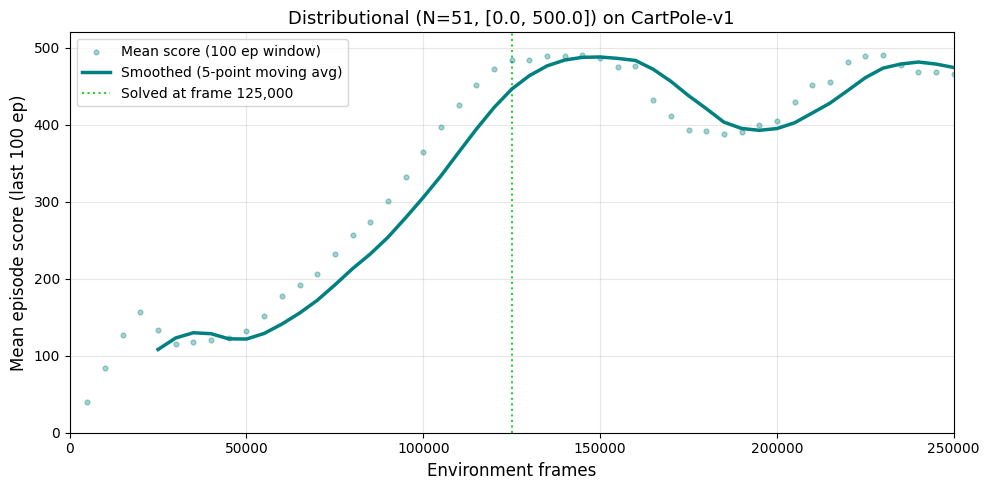

In [1]:
from DistributionModel import DistributionalAgent, DistributionalConfig, train, plot_results, plot_distribution

cfg = DistributionalConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsDis = train(cfg)
resultsDis.agent.save("Trained Models/DistributionModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = DistributionalAgent(env, DistributionalConfig())
agent.load("Trained Models/DistributionModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsDis)

In [3]:
import gymnasium as gym
from DistributionModel import DistributionalAgent, DistributionalConfig

env   = gym.make("CartPole-v1", render_mode="human")
agent = DistributionalAgent(env, DistributionalConfig())
agent.load("Trained Models/DistributionModel.pt")

agent.evaluate(env, n_episodes=1)
env.close()

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\DistributionModel.py:342: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature

Checkpoint loaded ← Trained Models/DistributionModel.pt  (step 250,000)


# Dueling Networks

## The Idea

Vanilla DQN estimates $Q(s, a)$ directly with a single network stream. This means that to update the value of any action, the network must have visited that specific $(s, a)$ pair.

Dueling DQN observes that $Q(s, a)$ can be decomposed into two separate quantities:

$$Q(s, a) = V(s) + A(s, a)$$

- $V(s)$ — the value of being in state $s$, regardless of which action is taken
- $A(s, a)$ — the advantage of action $a$ over the average action in state $s$

In many states, the choice of action has little impact on the outcome. In those states, learning $V(s)$ accurately is more useful than evaluating every action individually. By splitting the two streams, the network can update its estimate of $V(s)$ from any transition in that state, even if it hasn't tried every action.

## Architecture

The network shares a common feature extraction trunk, then splits into two separate heads:

```
Input (obs)
    ↓
Shared Trunk   →   feature representation
        ↙                         ↘
Value Head                   Advantage Head
Linear → ReLU → Linear(1)   Linear → ReLU → Linear(|A|)
    V(s)                          A(s, a)
```

The two outputs are recombined via the identifiable aggregation formula:

$$Q(s, a) = V(s) + A(s, a) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a')$$

Why the correction ?

Without the correction, $V$ and $A$ are not uniquely identifiable from $Q$ alone you could add a constant to $V$ and subtract it from every $A$ and get the same $Q$. The network has no incentive to learn meaningful values for each stream separately.

Subtracting the mean advantage forces the advantage stream to be zero-mean, which means:

$$V(s) = \frac{1}{|\mathcal{A}|} \sum_a Q(s, a)$$

Now $V(s)$ is uniquely pinned to the average Q-value across actions, and $A(s, a)$ represents the true relative advantage. The max is not used because it can shift discontinuously during training, making optimisation less stable.

*Reference: Wang et al. (2016), "Dueling Network Architectures for Deep Reinforcement Learning"*

  Dueling DQN — CartPole
  Trunk hidden  : 128
  Head hidden   : 128  (value + advantage)
  Replay buffer : 50,000
  Batch size    : 64
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 237  mean_R=  22.2  eps=0.505  loss=0.0171  fps=177  28s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 309  mean_R=  56.3  eps=0.010  loss=0.0291  fps=158  63s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 344  mean_R=  96.6  eps=0.010  loss=0.0473  fps=151  100s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 381  mean_R= 131.0  eps=0.010  loss=0.0713  fps=147  136s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 417  mean_R= 139.0  eps=0.010  loss=0.0927  fps=146  172s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 454  mean_R= 136.7  eps=0.010  loss=0.1037  fps=141  212s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 498  mean_R= 127.8  eps=0.010  loss=0.1001  fps=140  251s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 542  mean_R= 116.5  eps=0.010  loss=0.0979  fps=138  290s
[███░░░░░░░░░░░░░░░░░] 45,000/

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\DuelingModel.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

103.7
Plot saved → dueling_dqn_rewards.png


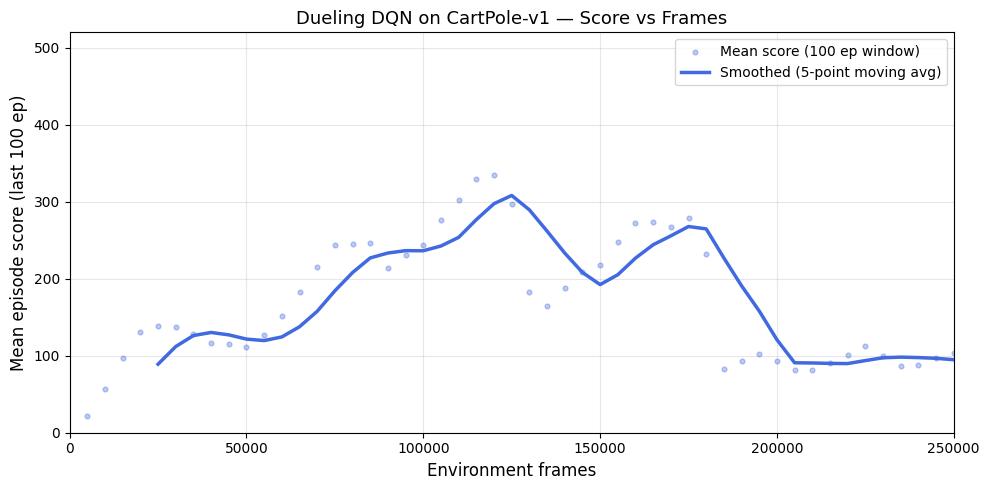

In [4]:
from DuelingModel import DuelingAgent, DuelingConfig, train, plot_results

cfg = DuelingConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsDueling = train(cfg)
resultsDueling.agent.save("Trained Models/DuelingModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = DuelingAgent(env, DuelingConfig())
agent.load("Trained Models/DuelingModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsDueling)

In [ ]:
import gymnasium as gym
from DuelingModel import DuelingAgent, DuelingConfig

env   = gym.make("CartPole-v1", render_mode="human")
agent = DuelingAgent(env, DuelingConfig())
agent.load("Trained Models/DuelingModel.pt")

agent.evaluate(env, n_episodes=3)
env.close()

Checkpoint loaded ← Trained Models/DuelingModel.pt  (step 250,000)


# Rainbow

We combine the six improvements to DQN into a single agent (Without Dueling). Each component targets a different weakness of vanilla DQN. Together they produce state-of-the-art performance and significantly outperforming any single component in isolation.

## The Six Components

### 1. Double DQN — fixes overestimation bias
Vanilla DQN uses the same network to select and evaluate the best next action, which inflates Q-values. Double DQN decouples the two:

$$y = r + \gamma \cdot Q_{\theta^-}(s', \underbrace{\arg\max_{a'} Q_\theta(s', a')}_{\text{policy net selects}})$$

### 2. Prioritized Replay — smarter sampling
Instead of sampling uniformly, transitions are sampled proportional to their TD error:

$$P(i) = \frac{p_i^\alpha}{\sum_j p_j^\alpha}, \qquad p_i = |\delta_i| + \varepsilon$$

IS weights $w_i = (N \cdot P(i))^{-\beta}$ correct the resulting bias. $\beta$ is annealed from $\beta_0 \to 1$.

### 3. Noisy Nets — learned exploration
Replaces $\varepsilon$-greedy with stochastic linear layers:

$$y = (\mu^w + \sigma^w \odot \varepsilon^w)\,x + (\mu^b + \sigma^b \odot \varepsilon^b)$$

$\sigma$ is a learnable parameter — the network self-anneals toward determinism as it gains confidence. No external exploration schedule needed.

### 4. Multi-Step Returns — faster reward propagation
Accumulates $n$ real rewards before bootstrapping:

$$G_t^{(n)} = \sum_{k=0}^{n-1} \gamma^k r_{t+k}, \qquad y = G_t^{(n)} + \gamma^n \max_{a'} Q(s_{t+n}, a')$$

Reduces bias from inaccurate Q-estimates early in training. Rainbow uses $n = 3$.

### 5. Distributional RL (C51) — learn the full return distribution
Instead of learning $\mathbb{E}[Z(s,a)]$, learns the full distribution $Z(s,a)$ over a fixed support of $N = 51$ atoms $\{z_i\}$. The Bellman operator shifts and projects the distribution:

$$\mathcal{T}z_i = r + \gamma z_i \quad \text{(clipped to } [V_\text{min}, V_\text{max}]\text{)}$$

Loss is cross-entropy rather than MSE: $\mathcal{L} = -\sum_i m_i \log p_i(s, a)$

### 6. Dueling Networks — separate state value and action advantage
Splits the network into two streams recombined via:

$$Q(s, a) = V(s) + A(s, a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s, a')$$

Allows $V(s)$ to be updated from any action, improving estimates for rarely-visited actions.


  Rainbow (with no Dueling) — CartPole
  Atoms         : 51  [0.0, 500.0]
  n-steps       : 3  (γ^n = 0.9703)
  PER α / β₀    : 0.6 / 0.4
  σ_init        : 0.5
  Max frames    : 250,000


[░░░░░░░░░░░░░░░░░░░░]  5,000/250,000  ep= 264  mean_R=  31.2  σ=0.0557  β=0.412  loss=2.6042  fps=130  39s
[░░░░░░░░░░░░░░░░░░░░] 10,000/250,000  ep= 307  mean_R=  71.8  σ=0.0395  β=0.424  loss=2.4391  fps=113  89s
[█░░░░░░░░░░░░░░░░░░░] 15,000/250,000  ep= 339  mean_R= 112.8  σ=0.0306  β=0.436  loss=2.2694  fps=107  140s
[█░░░░░░░░░░░░░░░░░░░] 20,000/250,000  ep= 360  mean_R= 153.8  σ=0.0259  β=0.448  loss=2.1869  fps=105  191s
[██░░░░░░░░░░░░░░░░░░] 25,000/250,000  ep= 374  mean_R= 188.1  σ=0.0240  β=0.460  loss=2.1397  fps=103  242s
[██░░░░░░░░░░░░░░░░░░] 30,000/250,000  ep= 385  mean_R= 224.2  σ=0.0228  β=0.472  loss=2.0737  fps=103  292s
[██░░░░░░░░░░░░░░░░░░] 35,000/250,000  ep= 395  mean_R= 262.5  σ=0.0223  β=0.484  loss=2.0367  fps=101  346s
[███░░░░░░░░░░░░░░░░░] 40,000/250,000  ep= 405  mea

c:\Users\oscar\OneDrive\Documents\Cours Dauphine\MASEF\Semestre 2\Reinforcement Learning\Project RAINBOW\RainbowModel.py:507: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  c

440.2
Plot saved → rainbow_rewards.png


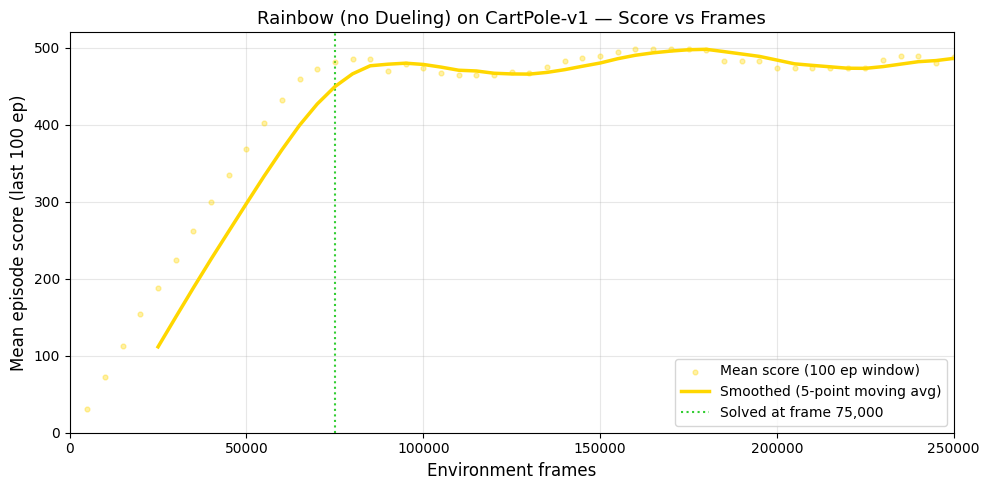

In [8]:
from RainbowModel import RainbowAgent, RainbowConfig, train, plot_results
#No Dueling
cfg = RainbowConfig(max_frames=250000, learning_rate=5e-4, render=False)
resultsRainbow = train(cfg)
resultsRainbow.agent.save("Trained Models/RainbowModel.pt")

import gymnasium as gym
env = gym.make("CartPole-v1")
agent = RainbowAgent(env, RainbowConfig())
agent.load("Trained Models/RainbowModel.pt")
print(agent.evaluate(env, n_episodes=20))
plot_results(resultsRainbow)

In [10]:
import gymnasium as gym
from RainbowModel import RainbowAgent, RainbowConfig

env   = gym.make("CartPole-v1", render_mode="human")
agent = RainbowAgent(env, RainbowConfig())
agent.load("Trained Models/RainbowModel.pt")

agent.evaluate(env, n_episodes=3)
env.close()

Checkpoint loaded ← Trained Models/RainbowModel.pt  (step 250,000)
